DATASET OVERVIEW
Total configurations:         25
Partition size range:         1 – 25
Tensor size range:            2 – 33,554,432 entries
Peak RSS at max partition:    23,174.62 MB (22.63 GB)

FITTING MEMORY VS TENSOR SIZE (log-log regression)
Log2(RSS MB) = 1.0421 * log2(tensor_size) + -11.4361
R² = 0.9934
Interpretation: RSS(MB) ≈ 2^-11.44 × tensor_size^1.04

EXTRAPOLATED SAFE MAX TENSOR SIZE
  Budget   32GB | safety=1.5× | max tensor =      29,339,133 | predicted RSS ≈ 21.33 GB
  Budget   32GB | safety=2.0× | max tensor =      22,261,689 | predicted RSS ≈ 16.00 GB
  Budget   32GB | safety=3.0× | max tensor =      15,086,338 | predicted RSS ≈ 10.67 GB
  Budget   40GB | safety=1.5× | max tensor =      36,344,654 | predicted RSS ≈ 26.67 GB
  Budget   40GB | safety=2.0× | max tensor =      27,577,276 | predicted RSS ≈ 20.00 GB
  Budget   40GB | safety=3.0× | max tensor =      18,688,614 | predicted RSS ≈ 13.33 GB
  Budget   48GB | safety=1.5× | max tensor =      43,293,387 | predicted

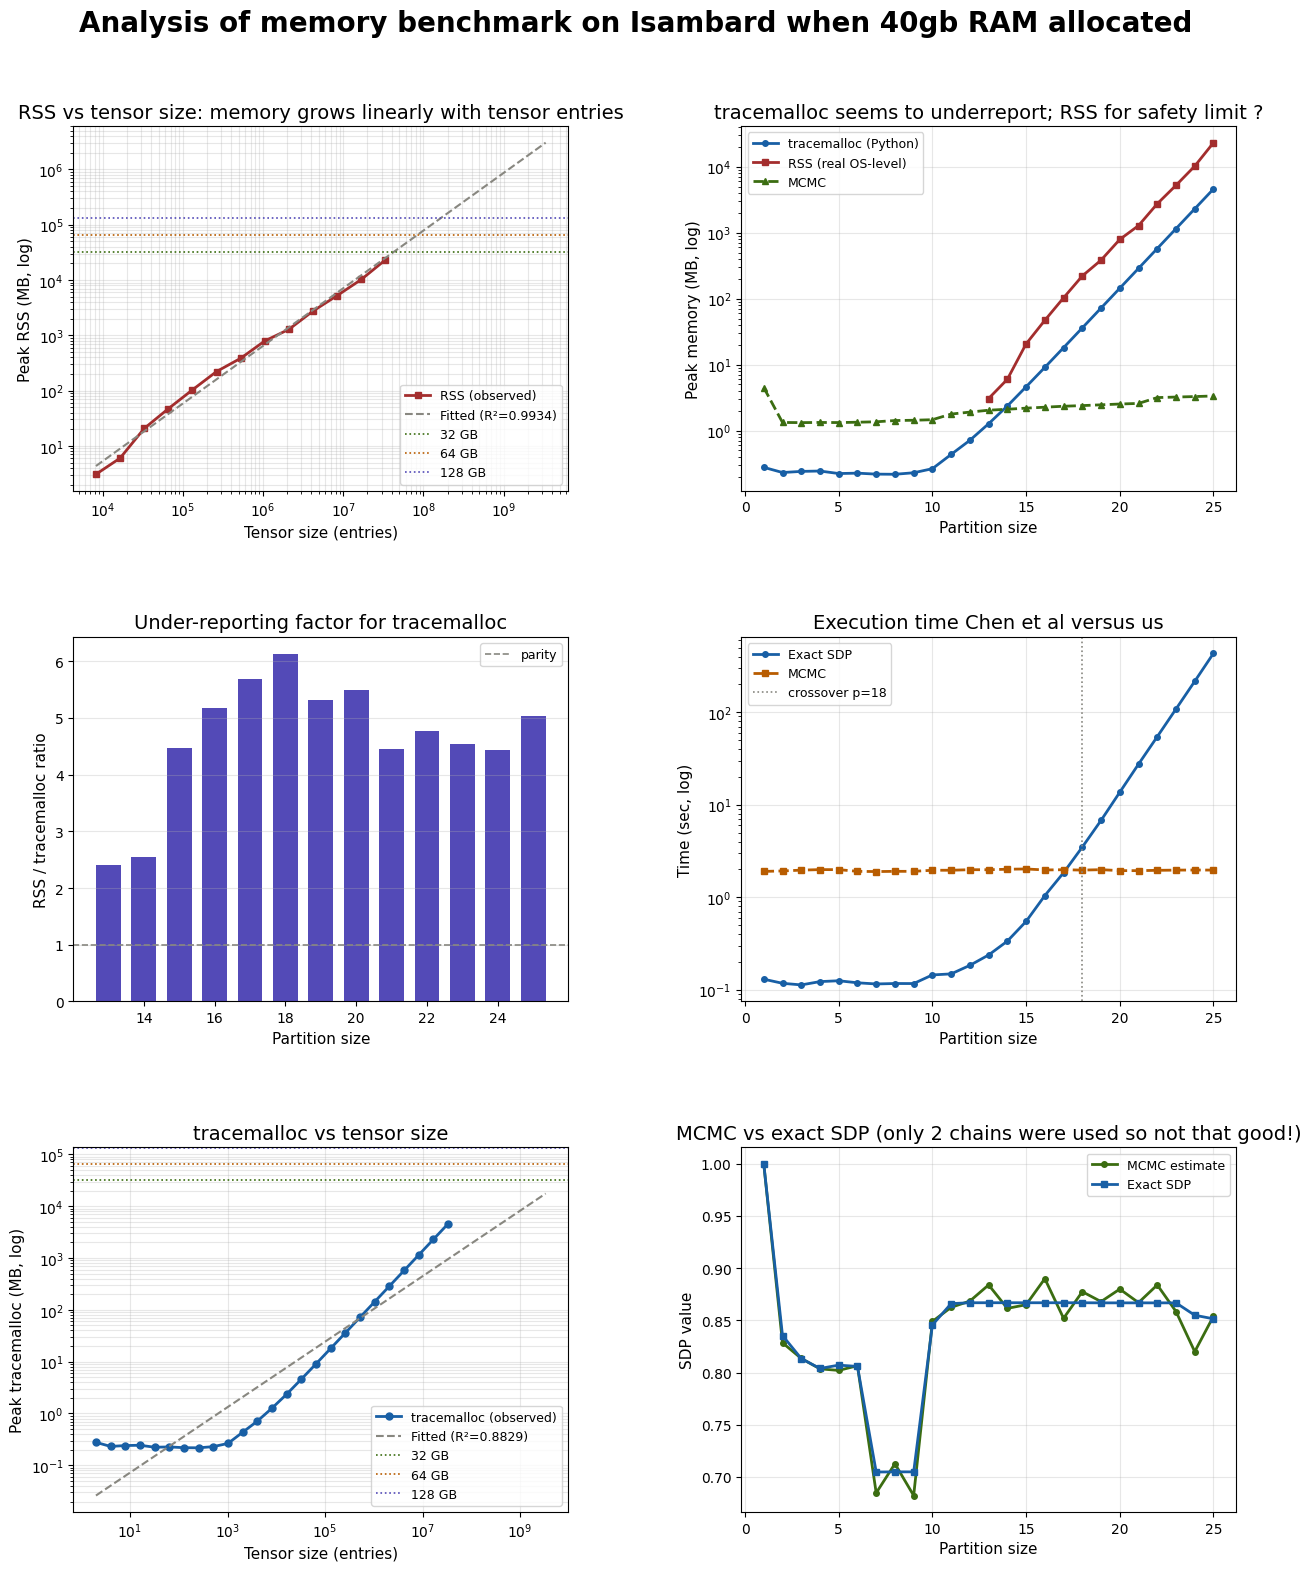

In [12]:
"""
Analyse the 40GB Isambard memory benchmark and extrapolate the safe
max_tensor_size threshold for 64GB and 128GB budgets.
"""
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv("growing_partition_benchmark_isambard_40gb.csv")

# Convenience columns
df['mem_ratio'] = df['exact_peak_rss_mb'] / df['exact_peak_memory_mb'].replace(0, np.nan)
df['tensor_bytes'] = df['max_partition_tensor_size'] * 8  # float64
df['tensor_mb'] = df['tensor_bytes'] / (1024 * 1024)
df['speedup'] = df['exact_time_sec'] / df['mcmc_avg_time_sec']

# ============================================================
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Total configurations:         {len(df)}")
print(f"Partition size range:         {df['max_partition_size'].min()} – {df['max_partition_size'].max()}")
print(f"Tensor size range:            {df['max_partition_tensor_size'].min():,} – {df['max_partition_tensor_size'].max():,} entries")
print(f"Peak RSS at max partition:    {df['exact_peak_rss_mb'].max():,.2f} MB "
      f"({df['exact_peak_rss_mb'].max()/1024:.2f} GB)")

# ============================================================
print("\n" + "=" * 70)
print("FITTING MEMORY VS TENSOR SIZE (log-log regression)")
print("=" * 70)
# Only use rows where RSS is meaningful (large partitions)
large = df[df['exact_peak_rss_mb'] > 1].copy()
log_tensor = np.log2(large['max_partition_tensor_size'])
log_rss = np.log2(large['exact_peak_rss_mb'])
slope_rss, intercept_rss, r_rss, _, _ = stats.linregress(log_tensor, log_rss)
print(f"Log2(RSS MB) = {slope_rss:.4f} * log2(tensor_size) + {intercept_rss:.4f}")
print(f"R² = {r_rss**2:.4f}")
print(f"Interpretation: RSS(MB) ≈ 2^{intercept_rss:.2f} × tensor_size^{slope_rss:.2f}")

def predict_rss_mb(tensor_size):
    """Predict RSS memory in MB for a given tensor size, using the fitted model."""
    return 2 ** (slope_rss * np.log2(tensor_size) + intercept_rss)

def max_tensor_for_budget(budget_gb, safety_factor=2.0):
    """
    Largest tensor size that keeps predicted RSS under budget_gb / safety_factor.
    Safety factor accounts for: (a) transient numpy spikes above steady-state peak,
    (b) other process overhead (Python interpreter, pgmpy model in memory), and
    (c) random variance between runs.
    """
    target_mb = (budget_gb * 1024) / safety_factor
    # RSS = 2^(slope * log2(t) + intercept) = target_mb
    # log2(t) = (log2(target_mb) - intercept) / slope
    log_t = (np.log2(target_mb) - intercept_rss) / slope_rss
    return int(2 ** log_t)

print("\n" + "=" * 70)
print("EXTRAPOLATED SAFE MAX TENSOR SIZE")
print("=" * 70)
for budget in [32, 40, 48, 64, 96, 128, 192, 256]:
    for sf in [1.5, 2.0, 3.0]:
        max_t = max_tensor_for_budget(budget, safety_factor=sf)
        predicted_mb = predict_rss_mb(max_t)
        print(f"  Budget {budget:4d}GB | safety={sf:.1f}× | "
              f"max tensor = {max_t:>15,} | predicted RSS ≈ {predicted_mb/1024:.2f} GB")

print("\n" + "=" * 70)
print("RECOMMENDED SETTINGS")
print("=" * 70)
for budget, label in [(64, "64GB node"), (128, "128GB node")]:
    # Use safety factor 2.0 — validated against observed 5-6× tracemalloc ratio
    max_t = max_tensor_for_budget(budget, safety_factor=2.0)
    predicted_mb = predict_rss_mb(max_t)
    # Round to a clean number (nearest power of 2)
    log2_clean = int(np.floor(np.log2(max_t)))
    clean_t = 2 ** log2_clean
    clean_mb = predict_rss_mb(clean_t)
    print(f"\n  {label}:")
    print(f"    max_tensor_entries = {clean_t:,} (= 2^{log2_clean})")
    print(f"    predicted peak RSS = {clean_mb/1024:.2f} GB")
    print(f"    peak partition size (binary BNs)   = {log2_clean}")
    print(f"    headroom = {budget - clean_mb/1024:.1f} GB")

# ============================================================
print("\n" + "=" * 70)
print("SANITY CHECK — observed data against fitted model")
print("=" * 70)
print(f"{'partition':>9} | {'tensor_size':>14} | {'RSS obs (MB)':>13} | {'RSS pred (MB)':>14} | {'error':>8}")
for _, r in large.iterrows():
    if r['max_partition_size'] % 2 == 1 or r['max_partition_size'] >= 20:
        predicted = predict_rss_mb(r['max_partition_tensor_size'])
        error = (predicted - r['exact_peak_rss_mb']) / r['exact_peak_rss_mb'] * 100
        print(f"{int(r['max_partition_size']):>9} | {int(r['max_partition_tensor_size']):>14,} | "
              f"{r['exact_peak_rss_mb']:>13.2f} | {predicted:>14.2f} | {error:>+7.1f}%")

# ============================================================
# PLOTS
# ============================================================
BLUE, RED, AMBER, GREEN, PURP, GRAY = '#185FA5', '#A32D2D', '#B85C00', '#3B6D11', '#534AB7', '#888780'

fig = plt.figure(figsize=(15, 18))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. RSS vs tensor size (log-log), with fitted line ──────────
ax1 = fig.add_subplot(gs[0, 0])
valid = df[df['exact_peak_rss_mb'] > 0]
ax1.loglog(valid['max_partition_tensor_size'], valid['exact_peak_rss_mb'],
           color=RED, lw=2, marker='s', ms=5, label='RSS (observed)')
# Fitted curve
t_fit = np.logspace(np.log10(large['max_partition_tensor_size'].min()),
                    np.log10(large['max_partition_tensor_size'].max() * 100), 100)
rss_fit = predict_rss_mb(t_fit)
ax1.loglog(t_fit, rss_fit, color=GRAY, ls='--', lw=1.5, label=f'Fitted (R²={r_rss**2:.4f})')
# Budget lines
for budget, color in [(32, GREEN), (64, AMBER), (128, PURP)]:
    ax1.axhline(budget * 1024, color=color, ls=':', lw=1.2, label=f'{budget} GB')
ax1.set_xlabel('Tensor size (entries)', fontsize=11)
ax1.set_ylabel('Peak RSS (MB, log)', fontsize=11)
ax1.set_title('RSS vs tensor size: memory grows linearly with tensor entries', fontsize=14)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3, which='both')

# ── 2. Memory comparison: tracemalloc vs RSS ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(df['max_partition_size'], df['exact_peak_memory_mb'].clip(lower=0.01),
             color=BLUE, lw=2, marker='o', ms=4, label='tracemalloc (Python)')
ax2.semilogy(valid['max_partition_size'], valid['exact_peak_rss_mb'],
             color=RED, lw=2, marker='s', ms=4, label='RSS (real OS-level)')
ax2.semilogy(df['max_partition_size'], df['mcmc_peak_memory_mb'],
             color=GREEN, lw=2, ls='--', marker='^', ms=4, label='MCMC')
ax2.set_xlabel('Partition size', fontsize=11)
ax2.set_ylabel('Peak memory (MB, log)', fontsize=11)
ax2.set_title('tracemalloc seems to underreport; RSS for safety limit ?', fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── 3. RSS/tracemalloc ratio ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
valid_ratio = df[(df['exact_peak_rss_mb'] > 1) & (df['exact_peak_memory_mb'] > 0)]
ax3.bar(valid_ratio['max_partition_size'], valid_ratio['mem_ratio'], color=PURP, width=0.7)
ax3.axhline(1.0, color=GRAY, ls='--', lw=1.2, label='parity')
ax3.set_xlabel('Partition size', fontsize=11)
ax3.set_ylabel('RSS / tracemalloc ratio', fontsize=11)
ax3.set_title('Under-reporting factor for tracemalloc', fontsize=14)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ── 4. Time comparison ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.semilogy(df['max_partition_size'], df['exact_time_sec'],
             color=BLUE, lw=2, marker='o', ms=4, label='Exact SDP')
ax4.semilogy(df['max_partition_size'], df['mcmc_avg_time_sec'],
             color=AMBER, lw=2, ls='--', marker='s', ms=4, label='MCMC')
crossover = df[df['speedup'] >= 1.0]
if len(crossover) > 0:
    c = crossover.iloc[0]
    ax4.axvline(c['max_partition_size'], color=GRAY, ls=':', lw=1.2,
                label=f"crossover p={int(c['max_partition_size'])}")
ax4.set_xlabel('Partition size', fontsize=11)
ax4.set_ylabel('Time (sec, log)', fontsize=11)
ax4.set_title('Execution time Chen et al versus us', fontsize=14)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ── 5. Safe max tensor for different budgets ──────────────────
#ax5 = fig.add_subplot(gs[2, 0])
#budgets = [32, 40, 48, 64, 96, 128, 192, 256]
#safety_factors = [1.5, 2.0, 3.0]
#colors_sf = [BLUE, PURP, RED]
#width = 0.25
#xx = np.arange(len(budgets))
#for i, (sf, color) in enumerate(zip(safety_factors, colors_sf)):
#    values = [max_tensor_for_budget(b, sf) for b in budgets]
#    log_values = [np.log2(v) for v in values]
#    ax5.bar(xx + (i - 1) * width, log_values, width, label=f'safety ×{sf:.1f}', color=color)
#ax5.set_xticks(xx)
#ax5.set_xticklabels([f'{b}GB' for b in budgets])
#ax5.set_xlabel('RAM budget', fontsize=11)
#ax5.set_ylabel('log2(max tensor entries)', fontsize=11)
#ax5.set_title('Safe max_tensor_entries by budget and safety factor', fontsize=14)
#ax5.legend(fontsize=9)
#ax5.grid(True, alpha=0.3, axis='y')
#
# Tracemalloc versus tensor size (linear scale)
ax7 = fig.add_subplot(gs[2, 0])
valid_tm = df[df['exact_peak_memory_mb'] > 0]
ax7.loglog(valid_tm['max_partition_tensor_size'], valid_tm['exact_peak_memory_mb'],
           color=BLUE, lw=2, marker='o', ms=5, label='tracemalloc (observed)')
 
# Log-log fit on the tracemalloc data
log_tensor_tm = np.log2(valid_tm['max_partition_tensor_size'])
log_tm = np.log2(valid_tm['exact_peak_memory_mb'])
slope_tm_fit, intercept_tm_fit, r_tm_fit, _, _ = stats.linregress(log_tensor_tm, log_tm)
 
def predict_tm_mb(tensor_size):
    return 2 ** (slope_tm_fit * np.log2(tensor_size) + intercept_tm_fit)
 
# Fitted curve
t_fit_tm = np.logspace(np.log10(valid_tm['max_partition_tensor_size'].min()),
                       np.log10(valid_tm['max_partition_tensor_size'].max() * 100), 100)
tm_fit = predict_tm_mb(t_fit_tm)
ax7.loglog(t_fit_tm, tm_fit, color=GRAY, ls='--', lw=1.5, label=f'Fitted (R²={r_tm_fit**2:.4f})')
 
# Budget lines
for budget, color in [(32, GREEN), (64, AMBER), (128, PURP)]:
    ax7.axhline(budget * 1024, color=color, ls=':', lw=1.2, label=f'{budget} GB')
 
ax7.set_xlabel('Tensor size (entries)', fontsize=11)
ax7.set_ylabel('Peak tracemalloc (MB, log)', fontsize=11)
ax7.set_title('tracemalloc vs tensor size', fontsize=14)
ax7.legend(fontsize=9, loc='lower right')
ax7.grid(True, alpha=0.3, which='both')

# ── 6. MCMC accuracy ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df['max_partition_size'], df['mcmc_avg_estimate'], color=GREEN, lw=2, marker='o', ms=4,
         label='MCMC estimate')
ax6.plot(df['max_partition_size'], df['exact_sdp_result'], color=BLUE, lw=2, marker='s', ms=4,
         label='Exact SDP')
ax6.set_xlabel('Partition size', fontsize=11)
ax6.set_ylabel('SDP value', fontsize=11)
ax6.set_title('MCMC vs exact SDP (only 2 chains were used so not that good!)', fontsize=14)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

fig.suptitle('Analysis of memory benchmark on Isambard when 40gb RAM allocated',
             fontsize=20, fontweight='bold', y=0.945)
plt.savefig('benchmark_40gb_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')

print("\nPlot saved to benchmark_40gb_analysis.png")
plt.show()

In [2]:
"""
Analyse the 40GB Isambard memory benchmark and extrapolate the safe
max_tensor_size threshold for 64GB and 128GB budgets.

Produces separate high-resolution (8×6 in, 300 dpi) figures suitable
for inclusion in a paper.
"""
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Matplotlib publication style ────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.labelsize':     12,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         150,        # screen preview
    'savefig.dpi':        300,        # saved files
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linewidth':     0.6,
    'lines.linewidth':    1.8,
    'lines.markersize':   5,
})

FIG_W, FIG_H = 8, 6          # inches – standard single-column paper figure

BLUE, RED, AMBER, GREEN, PURP, GRAY = (
    '#185FA5', '#A32D2D', '#B85C00', '#3B6D11', '#534AB7', '#888780'
)

SAVE_KWARGS = dict(bbox_inches='tight', facecolor='white')

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("growing_partition_benchmark_isambard_40gb.csv")

df['mem_ratio']   = df['exact_peak_rss_mb'] / df['exact_peak_memory_mb'].replace(0, np.nan)
df['tensor_bytes']= df['max_partition_tensor_size'] * 8   # float64
df['tensor_mb']   = df['tensor_bytes'] / (1024 * 1024)
df['speedup']     = df['exact_time_sec'] / df['mcmc_avg_time_sec']

# ── Regression: RSS vs tensor size (log-log) ─────────────────────────────────
large = df[df['exact_peak_rss_mb'] > 1].copy()
log_tensor = np.log2(large['max_partition_tensor_size'])
log_rss    = np.log2(large['exact_peak_rss_mb'])
slope_rss, intercept_rss, r_rss, _, _ = stats.linregress(log_tensor, log_rss)

print("=" * 70)
print("FITTING MEMORY VS TENSOR SIZE (log-log regression)")
print("=" * 70)
print(f"Log2(RSS MB) = {slope_rss:.4f} * log2(tensor_size) + {intercept_rss:.4f}")
print(f"R² = {r_rss**2:.4f}")

def predict_rss_mb(tensor_size):
    return 2 ** (slope_rss * np.log2(tensor_size) + intercept_rss)

def max_tensor_for_budget(budget_gb, safety_factor=2.0):
    target_mb = (budget_gb * 1024) / safety_factor
    log_t = (np.log2(target_mb) - intercept_rss) / slope_rss
    return int(2 ** log_t)

# ── Regression: tracemalloc vs tensor size (log-log) ────────────────────────
valid_tm = df[df['exact_peak_memory_mb'] > 0]
slope_tm, intercept_tm, r_tm, _, _ = stats.linregress(
    np.log2(valid_tm['max_partition_tensor_size']),
    np.log2(valid_tm['exact_peak_memory_mb'])
)

def predict_tm_mb(tensor_size):
    return 2 ** (slope_tm * np.log2(tensor_size) + intercept_tm)

# ── Extrapolation summary ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("EXTRAPOLATED SAFE MAX TENSOR SIZE")
print("=" * 70)
for budget in [32, 40, 48, 64, 96, 128, 192, 256]:
    for sf in [1.5, 2.0, 3.0]:
        max_t      = max_tensor_for_budget(budget, safety_factor=sf)
        pred_mb    = predict_rss_mb(max_t)
        print(f"  Budget {budget:4d}GB | safety={sf:.1f}× | "
              f"max tensor = {max_t:>15,} | predicted RSS ≈ {pred_mb/1024:.2f} GB")

print("\n" + "=" * 70)
print("RECOMMENDED SETTINGS")
print("=" * 70)
for budget, label in [(64, "64GB node"), (128, "128GB node")]:
    max_t      = max_tensor_for_budget(budget, safety_factor=2.0)
    log2_clean = int(np.floor(np.log2(max_t)))
    clean_t    = 2 ** log2_clean
    clean_mb   = predict_rss_mb(clean_t)
    print(f"\n  {label}:")
    print(f"    max_tensor_entries = {clean_t:,} (= 2^{log2_clean})")
    print(f"    predicted peak RSS = {clean_mb/1024:.2f} GB")
    print(f"    headroom = {budget - clean_mb/1024:.1f} GB")

# ── Sanity check ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SANITY CHECK — observed data against fitted model")
print("=" * 70)
print(f"{'partition':>9} | {'tensor_size':>14} | {'RSS obs (MB)':>13} | "
      f"{'RSS pred (MB)':>14} | {'error':>8}")
for _, r in large.iterrows():
    if r['max_partition_size'] % 2 == 1 or r['max_partition_size'] >= 20:
        predicted = predict_rss_mb(r['max_partition_tensor_size'])
        error     = (predicted - r['exact_peak_rss_mb']) / r['exact_peak_rss_mb'] * 100
        print(f"{int(r['max_partition_size']):>9} | {int(r['max_partition_tensor_size']):>14,} | "
              f"{r['exact_peak_rss_mb']:>13.2f} | {predicted:>14.2f} | {error:>+7.1f}%")


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — RSS vs tensor size (log-log) with fitted line
# ════════════════════════════════════════════════════════════════════════════
valid = df[df['exact_peak_rss_mb'] > 0]
t_fit = np.logspace(
    np.log10(large['max_partition_tensor_size'].min()),
    np.log10(large['max_partition_tensor_size'].max() * 100), 200
)

fig1, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.loglog(valid['max_partition_tensor_size'], valid['exact_peak_rss_mb'],
          color=RED, marker='s', label='RSS (observed)')
ax.loglog(t_fit, predict_rss_mb(t_fit),
          color=GRAY, ls='--', lw=1.4,
          label=f'Power-law fit  ($R^2={r_rss**2:.4f}$)')
for budget, color, ls in [(32, GREEN, ':'), (64, AMBER, '-.'), (128, PURP, ':')]:
    ax.axhline(budget * 1024, color=color, ls=ls, lw=1.2, label=f'{budget} GB limit')
ax.set_xlabel('Tensor size (entries)')
ax.set_ylabel('Peak RSS (MB)')
ax.set_title('Peak RSS vs. tensor size')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
fig1.tight_layout()
fig1.savefig('fig1_rss_vs_tensor.png', **SAVE_KWARGS)
print("\nSaved fig1_rss_vs_tensor.png")
plt.close(fig1)


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — tracemalloc vs RSS vs MCMC memory (semi-log)
# ════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.semilogy(df['max_partition_size'], df['exact_peak_memory_mb'].clip(lower=0.01),
            color=BLUE, marker='o', label='tracemalloc (Python-tracked)')
#ax.semilogy(valid['max_partition_size'], valid['exact_peak_rss_mb'],
#            color=RED, marker='s', label='RSS (OS-level)')
ax.semilogy(df['max_partition_size'], df['mcmc_peak_memory_mb'],
            color=GREEN, ls='--', marker='^', label='MCMC peak')
ax.set_xlabel('Partition size')
ax.set_ylabel('Peak memory (MB)')
ax.set_title('Memory profiling: tracemalloc vs. MH')
ax.legend()
fig2.tight_layout()
fig2.savefig('fig2_memory_comparison.png', **SAVE_KWARGS)
print("Saved fig2_memory_comparison.png")
plt.close(fig2)


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — RSS / tracemalloc under-reporting ratio
# ════════════════════════════════════════════════════════════════════════════
valid_ratio = df[(df['exact_peak_rss_mb'] > 1) & (df['exact_peak_memory_mb'] > 0)]

fig3, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.bar(valid_ratio['max_partition_size'], valid_ratio['mem_ratio'],
       color=PURP, width=0.7, alpha=0.85)
ax.axhline(1.0, color=GRAY, ls='--', lw=1.2, label='Parity (ratio = 1)')
ax.set_xlabel('Partition size')
ax.set_ylabel('RSS / tracemalloc ratio')
ax.set_title('tracemalloc under-reporting factor relative to OS RSS')
ax.legend()
fig3.tight_layout()
fig3.savefig('fig3_underreporting_ratio.png', **SAVE_KWARGS)
print("Saved fig3_underreporting_ratio.png")
plt.close(fig3)


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Execution time: exact SDP vs MCMC
# ════════════════════════════════════════════════════════════════════════════
crossover = df[df['speedup'] >= 1.0]

fig4, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.semilogy(df['max_partition_size'], df['exact_time_sec'],
            color=BLUE, marker='o', label='Exact SDP')
ax.semilogy(df['max_partition_size'], df['mcmc_avg_time_sec'],
            color=AMBER, ls='--', marker='s', label='MCMC')
if len(crossover) > 0:
    c = crossover.iloc[0]
    ax.axvline(c['max_partition_size'], color=GRAY, ls=':', lw=1.2,
               label=f"Crossover at $p={int(c['max_partition_size'])}$")
ax.set_xlabel('Partition size')
ax.set_ylabel('Execution time (s)')
ax.set_title('Execution time: exact inference vs. MCMC')
ax.legend()
fig4.tight_layout()
fig4.savefig('fig4_execution_time.png', **SAVE_KWARGS)
print("Saved fig4_execution_time.png")
plt.close(fig4)


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — tracemalloc vs tensor size (log-log) with fitted line
# ════════════════════════════════════════════════════════════════════════════
t_fit_tm = np.logspace(
    np.log10(valid_tm['max_partition_tensor_size'].min()),
    np.log10(valid_tm['max_partition_tensor_size'].max() * 100), 200
)

fig5, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.loglog(valid_tm['max_partition_tensor_size'], valid_tm['exact_peak_memory_mb'],
          color=BLUE, marker='o', label='tracemalloc (observed)')
ax.loglog(t_fit_tm, predict_tm_mb(t_fit_tm),
          color=GRAY, ls='--', lw=1.4,
          label=f'Power-law fit  ($R^2={r_tm**2:.4f}$)')
for budget, color, ls in [(32, GREEN, ':'), (64, AMBER, '-.'), (128, PURP, ':')]:
    ax.axhline(budget * 1024, color=color, ls=ls, lw=1.2, label=f'{budget} GB limit')
ax.set_xlabel('Tensor size (entries)')
ax.set_ylabel('Peak tracemalloc (MB)')
ax.set_title('Python-tracked (tracemalloc) memory vs. tensor size')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
fig5.tight_layout()
fig5.savefig('fig5_tracemalloc_vs_tensor.png', **SAVE_KWARGS)
print("Saved fig5_tracemalloc_vs_tensor.png")
plt.close(fig5)


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — MCMC vs exact SDP result accuracy
# ════════════════════════════════════════════════════════════════════════════
fig6, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.plot(df['max_partition_size'], df['mcmc_avg_estimate'],
        color=GREEN, marker='o', label='MCMC estimate')
ax.plot(df['max_partition_size'], df['exact_sdp_result'],
        color=BLUE, marker='s', label='Exact SDP')
ax.set_xlabel('Partition size')
ax.set_ylabel('SDP value')
ax.set_title('MCMC estimate vs. exact SDP result')
ax.legend()
fig6.tight_layout()
fig6.savefig('fig6_mcmc_vs_exact.png', **SAVE_KWARGS)
print("Saved fig6_mcmc_vs_exact.png")
plt.close(fig6)

print("\nAll figures saved (300 dpi, 8×6 in).")

FITTING MEMORY VS TENSOR SIZE (log-log regression)
Log2(RSS MB) = 1.0421 * log2(tensor_size) + -11.4361
R² = 0.9934

EXTRAPOLATED SAFE MAX TENSOR SIZE
  Budget   32GB | safety=1.5× | max tensor =      29,339,133 | predicted RSS ≈ 21.33 GB
  Budget   32GB | safety=2.0× | max tensor =      22,261,689 | predicted RSS ≈ 16.00 GB
  Budget   32GB | safety=3.0× | max tensor =      15,086,338 | predicted RSS ≈ 10.67 GB
  Budget   40GB | safety=1.5× | max tensor =      36,344,654 | predicted RSS ≈ 26.67 GB
  Budget   40GB | safety=2.0× | max tensor =      27,577,276 | predicted RSS ≈ 20.00 GB
  Budget   40GB | safety=3.0× | max tensor =      18,688,614 | predicted RSS ≈ 13.33 GB
  Budget   48GB | safety=1.5× | max tensor =      43,293,387 | predicted RSS ≈ 32.00 GB
  Budget   48GB | safety=2.0× | max tensor =      32,849,775 | predicted RSS ≈ 24.00 GB
  Budget   48GB | safety=3.0× | max tensor =      22,261,689 | predicted RSS ≈ 16.00 GB
  Budget   64GB | safety=1.5× | max tensor =      57,057,